## 数据预处理

In [12]:
# ==============================
# 1. 导入所需库
# ==============================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [13]:
# ==============================
# 2. 加载数据
# ==============================

# 读取CSV文件
import os
os.getcwd()
os.chdir("C:\\Users\\21041\\Desktop")
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

# 查看前5行数据
print("数据前5行：")
print(df.head())

# 查看数据基本信息
print("\n数据基本信息：")
print(df.info())


数据前5行：
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2

In [14]:
# ==============================
# 3. 描述性统计分析
# ==============================

print("\n描述性统计分析：")
print(df.describe())

# 查看每一列的数据类型
print("\n各字段数据类型：")
print(df.dtypes)



描述性统计分析：
              age     anaemia  creatinine_phosphokinase    diabetes  \
count  299.000000  299.000000                299.000000  299.000000   
mean    60.833893    0.431438                581.839465    0.418060   
std     11.894809    0.496107                970.287881    0.494067   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                116.500000    0.000000   
50%     60.000000    0.000000                250.000000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max     95.000000    1.000000               7861.000000    1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count         299.000000           299.000000     299.000000   
mean           38.083612             0.351171  263358.029264   
std            11.834841             0.478136   97804.236869   
min            14.000000             0.000000   25100.000000   
25%            30.000000      

In [15]:
# ==============================
# 4. 检查缺失值
# ==============================

print("\n各字段缺失值数量：")
print(df.isnull().sum())

# 判断是否存在缺失值
if df.isnull().sum().sum() == 0:
    print("\n结果：数据中不存在缺失值，无需进行缺失值处理。")
else:
    print("\n存在缺失值，可采用均值、中位数或众数进行填充。")
    # 示例：使用中位数填充
    df = df.fillna(df.median(numeric_only=True))


各字段缺失值数量：
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

结果：数据中不存在缺失值，无需进行缺失值处理。


In [16]:
# ==============================
# 5. 检查重复值
# ==============================

print("\n重复数据数量：")
print(df.duplicated().sum())

# 删除重复值（如果存在）
df = df.drop_duplicates()



重复数据数量：
0


In [17]:
# ==============================
# 6. 检查异常值（IQR方法）
# ==============================

print("\n==========异常值检测==========")

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print("{} 异常值数量：{}".format(col, len(outliers)))



==========异常值检测==========
age 异常值数量：0
anaemia 异常值数量：0
creatinine_phosphokinase 异常值数量：29
diabetes 异常值数量：0
ejection_fraction 异常值数量：2
high_blood_pressure 异常值数量：0
platelets 异常值数量：21
serum_creatinine 异常值数量：29
serum_sodium 异常值数量：4
sex 异常值数量：0
smoking 异常值数量：0
time 异常值数量：0
DEATH_EVENT 异常值数量：0


In [18]:
# ==============================
# 7. 异常值处理（Winsorization思想）
# 将异常值限制在上下界
# ==============================

df_processed = df.copy()

for col in numeric_columns:

    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_processed[col] = np.where(df_processed[col] < lower,
                                 lower,
                                 df_processed[col])

    df_processed[col] = np.where(df_processed[col] > upper,
                                 upper,
                                 df_processed[col])

print("\n异常值处理完成。")



异常值处理完成。


In [20]:
# ==============================
# 8. 判断是否需要标准化
# ==============================

print("\n各变量取值范围：")

for col in numeric_columns:
    print(col,
          "最小值：", df_processed[col].min(),
          "最大值：", df_processed[col].max())



各变量取值范围：
age 最小值： 40.0 最大值： 95.0
anaemia 最小值： 0.0 最大值： 1.0
creatinine_phosphokinase 最小值： 23.0 最大值： 1280.25
diabetes 最小值： 0.0 最大值： 1.0
ejection_fraction 最小值： 14.0 最大值： 67.5
high_blood_pressure 最小值： 0.0 最大值： 1.0
platelets 最小值： 76000.0 最大值： 440000.0
serum_creatinine 最小值： 0.5 最大值： 2.1499999999999995
serum_sodium 最小值： 125.0 最大值： 148.0
sex 最小值： 0.0 最大值： 1.0
smoking 最小值： 0.0 最大值： 1.0
time 最小值： 4.0 最大值： 285.0
DEATH_EVENT 最小值： 0.0 最大值： 1.0


In [21]:
# ==============================
# 9. 数据标准化（StandardScaler）
# ==============================

# 去掉标签列(DEATH_EVENT)后进行标准化
feature_columns = df_processed.columns.drop("DEATH_EVENT")

scaler = StandardScaler()

df_standard = df_processed.copy()

df_standard[feature_columns] = scaler.fit_transform(
    df_processed[feature_columns]
)

print("\n标准化后的数据：")
print(df_standard.head())



标准化后的数据：
        age   anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  1.192945 -0.871105                  0.410040 -0.847579          -1.545801   
1 -0.491279 -0.871105                  2.224599 -0.847579          -0.002867   
2  0.350833 -0.871105                 -0.723004 -0.847579          -1.545801   
3 -0.912335  1.147968                 -0.813959 -0.847579          -1.545801   
4  0.350833  1.147968                 -0.686622  1.179830          -1.545801   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium       sex  \
0             1.359272   0.071750          1.514665     -1.649172  0.735688   
1            -0.735688   0.051564         -0.306161     -0.175024  0.735688   
2            -0.735688  -1.194509          0.149046     -1.894864  0.735688   
3            -0.735688  -0.604408          1.514665      0.070667  0.735688   
4            -0.735688   0.833964          2.083673     -2.877629 -1.359272   

    smoking      time  DEATH_EVENT

## 因子检验

In [22]:
# 数据可视化
import matplotlib.pyplot as plt
import seaborn as sns


# 统计检验
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu


# 机器学习模型
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


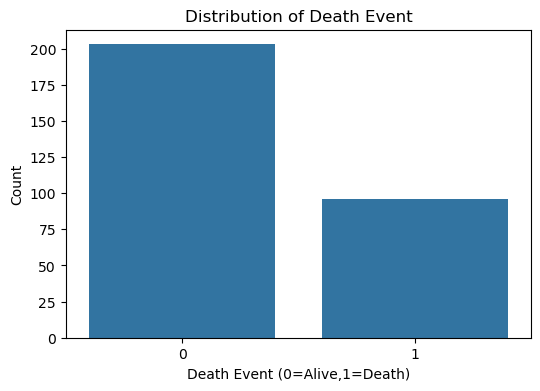

In [23]:
# ==============================
# 查看死亡事件比例
# ==============================


print(df["DEATH_EVENT"].value_counts())

# 绘制死亡人数分布

plt.figure(figsize=(6,4))

sns.countplot(
    x="DEATH_EVENT",
    data=df
)

plt.title(
    "Distribution of Death Event"
)

plt.xlabel(
    "Death Event (0=Alive,1=Death)"
)

plt.ylabel(
    "Count"
)

plt.show()

### 相关性分析

In [24]:
# ==============================
# 计算相关性矩阵
# ==============================
corr_matrix = df.corr()

print(
    corr_matrix["DEATH_EVENT"]
    .sort_values(
        ascending=False
    )
)

DEATH_EVENT                 1.000000
serum_creatinine            0.294278
age                         0.253729
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
diabetes                   -0.001943
sex                        -0.004316
smoking                    -0.012623
platelets                  -0.049139
serum_sodium               -0.195204
ejection_fraction          -0.268603
time                       -0.526964
Name: DEATH_EVENT, dtype: float64


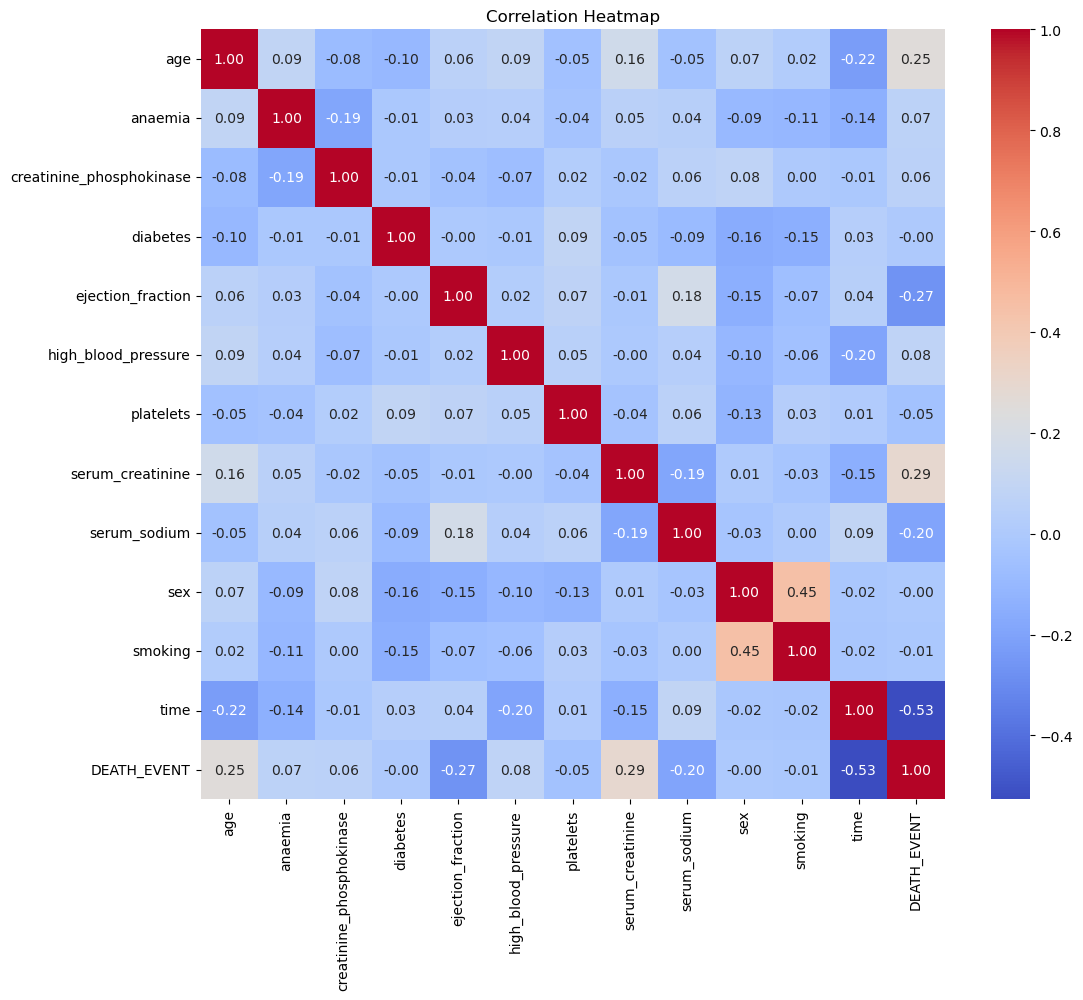

In [25]:
# ==============================
# 绘制相关性热力图
# ==============================

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

### 统计学检验寻找危险因素

In [26]:
# ==============================
# Mann-Whitney U检验
# ==============================

features = df.drop(
    columns=["DEATH_EVENT"]
).columns

results=[]

for feature in features:

    # 存活组
    alive = df[
        df["DEATH_EVENT"]==0
    ][feature]

    # 死亡组
    death = df[
        df["DEATH_EVENT"]==1
    ][feature]

    # U检验

    stat,p = mannwhitneyu(
        alive,
        death
    )

    results.append(
        [
            feature,
            stat,
            p
        ]
    )

# 转换为DataFrame

mw_result = pd.DataFrame(
    results,
    columns=[
        "Feature",
        "U_value",
        "p_value"
    ]
)

# 按p值排序

mw_result = mw_result.sort_values(
    by="p_value"
)

print(
    mw_result
)

                     Feature  U_value       p_value
11                      time  16288.5  6.852197e-21
7           serum_creatinine   5298.0  1.580998e-10
4          ejection_fraction  13176.5  7.368249e-07
0                        age   7121.0  1.667518e-04
8               serum_sodium  12261.5  2.927557e-04
5        high_blood_pressure   8953.5  1.710164e-01
1                    anaemia   9059.0  2.529704e-01
6                  platelets  10300.5  4.255585e-01
2   creatinine_phosphokinase   9460.0  6.840400e-01
10                   smoking   9867.0  8.281900e-01
9                        sex   9787.0  9.412922e-01
3                   diabetes   9764.0  9.739131e-01


In [27]:
# ==============================
# 筛选显著因素
# ==============================

significant_features = mw_result[
    mw_result["p_value"] < 0.05
]

print(
    "显著危险因素:"
)

print(
    significant_features
)

显著危险因素:
              Feature  U_value       p_value
11               time  16288.5  6.852197e-21
7    serum_creatinine   5298.0  1.580998e-10
4   ejection_fraction  13176.5  7.368249e-07
0                 age   7121.0  1.667518e-04
8        serum_sodium  12261.5  2.927557e-04


### 随机森林特征重要性分析

In [28]:
# ==============================
# 随机森林特征重要性
# ==============================

X = df.drop(
    columns=["DEATH_EVENT"]
)

y = df["DEATH_EVENT"]


# 划分训练测试集

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# 建立随机森林模型

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)


# 获取特征重要性

importance = pd.DataFrame(
    {
        "Feature":X.columns,
        "Importance":rf.feature_importances_
    }
)


importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(
    importance
)

                     Feature  Importance
11                      time    0.379166
7           serum_creatinine    0.152758
4          ejection_fraction    0.114497
0                        age    0.084507
2   creatinine_phosphokinase    0.076150
6                  platelets    0.074308
8               serum_sodium    0.063555
1                    anaemia    0.013364
10                   smoking    0.011202
3                   diabetes    0.010851
9                        sex    0.010613
5        high_blood_pressure    0.009029


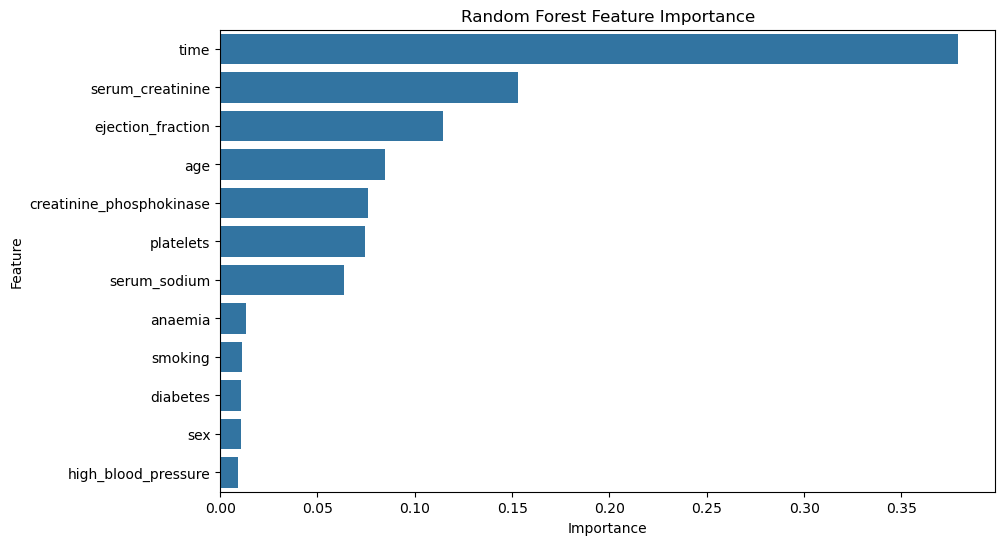

In [29]:
# ==============================
# 绘制特征重要性
# ==============================

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

In [30]:
# ==============================
# 输出前三危险因素
# ==============================

top3 = importance.head(3)

print(
    "影响死亡风险最大的前三个指标:"
)

print(top3)

影响死亡风险最大的前三个指标:
              Feature  Importance
11               time    0.379166
7    serum_creatinine    0.152758
4   ejection_fraction    0.114497


## 概率预测

In [33]:
import sys
print(sys.executable)
!"C:\Program Files\anaconda3\python.exe" -m pip install xgboost

C:\Program Files\anaconda3\python.exe
Defaulting to user installation because normal site-packages is not writeable


In [34]:
!"C:\Program Files\anaconda3\python.exe" -m pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/351.2 MB 2.2 MB/s eta 0:02:38
   ---------------------------------------- 1.3/351.2 MB 2.0 MB/s eta 0:02:52
   ---------------------------------------- 2.6/351.2 MB 3.2 MB/s eta 0:01:49
   ---------------------------------------- 3.4/351.2 MB 3.7 MB/s eta 0:01:34
    --------------------------------------- 5.2/351.2 MB 4.3 MB/s eta 0:01:21
    --------------------------------------- 6.0/351.2 MB 4.4 MB/s eta 0:01:19
    --------------------------------------- 7.1/351.2 MB 4.2 MB/s eta 0:01:22
    --------------------------------------- 8.7/351.2 MB 4.8 MB/s eta 0:01:12
   - ---------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [35]:
# 传统机器学习模型
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 深度学习
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 模型评价
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score
)

# 可视化
import matplotlib.pyplot as plt

In [36]:
# ===============================
# 特征与标签划分
# ===============================

X = df.drop(
    columns=["DEATH_EVENT"]
)

y = df["DEATH_EVENT"]

print(
    X.columns
)

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time'],
      dtype='object')


In [37]:
# ===============================
# 数据划分
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(
    X_train.shape,
    X_test.shape
)

(239, 12) (60, 12)


In [38]:
# ===============================
# 数据标准化
# ===============================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [ ]:
#### 机器学习

In [39]:
# ===============================
# Logistic Regression
# ===============================

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_prob = lr_model.predict_proba(
    X_test_scaled
)[:,1]

lr_pred = lr_model.predict(
    X_test_scaled
)

In [40]:
# ===============================
# Random Forest
# ===============================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_prob = rf_model.predict_proba(
    X_test
)[:,1]

rf_pred = rf_model.predict(
    X_test
)

In [41]:
# ===============================
# XGBoost
# ===============================

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_prob = xgb_model.predict_proba(
    X_test
)[:,1]

xgb_pred = xgb_model.predict(
    X_test
)

#### 深度学习

In [42]:
# ===============================
# MLP神经网络
# ===============================


mlp_model = Sequential()

mlp_model.add(
    Dense(
        64,
        activation="relu",
        input_dim=X_train_scaled.shape[1]
    )
)

mlp_model.add(
    Dropout(0.3)
)

mlp_model.add(
    Dense(
        32,
        activation="relu"
    )
)

# 输出死亡概率
mlp_model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)


mlp_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


mlp_model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    verbose=0
)


mlp_prob = mlp_model.predict(
    X_test_scaled
).ravel()

mlp_pred = (
    mlp_prob > 0.5
).astype(int)

C:\Users\21041\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


In [43]:
# ===============================
# 模型评价函数
# ===============================

def evaluate_model(
    name,
    y_true,
    y_pred,
    y_prob
):

    print("\n",name)

    print(
        "Accuracy:",
        accuracy_score(
            y_true,
            y_pred
        )
    )

    print(
        "Precision:",
        precision_score(
            y_true,
            y_pred
        )
    )

    print(
        "Recall:",
        recall_score(
            y_true,
            y_pred
        )
    )

    print(
        "F1-score:",
        f1_score(
            y_true,
            y_pred
        )
    )

    print(
        "AUC:",
        roc_auc_score(
            y_true,
            y_prob
        )
    )

In [44]:
# ===============================
# 模型评价
# ===============================

evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)

evaluate_model(
    "MLP Neural Network",
    y_test,
    mlp_pred,
    mlp_prob
)


 Logistic Regression
Accuracy: 0.8166666666666667
Precision: 0.7857142857142857
Recall: 0.5789473684210527
F1-score: 0.6666666666666666
AUC: 0.858793324775353

 Random Forest
Accuracy: 0.8166666666666667
Precision: 0.7857142857142857
Recall: 0.5789473684210527
F1-score: 0.6666666666666666
AUC: 0.8825417201540436

 XGBoost
Accuracy: 0.8166666666666667
Precision: 0.8333333333333334
Recall: 0.5263157894736842
F1-score: 0.6451612903225806
AUC: 0.8356867779204107

 MLP Neural Network
Accuracy: 0.7333333333333333
Precision: 0.6
Recall: 0.47368421052631576
F1-score: 0.5294117647058824
AUC: 0.7817715019255456


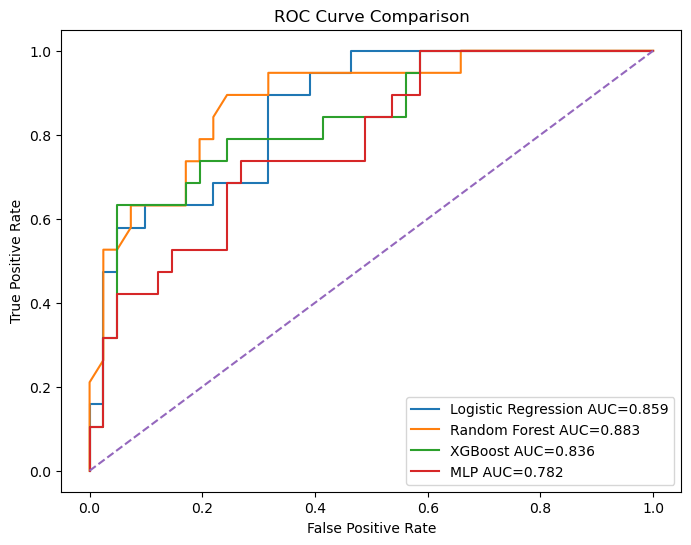

In [45]:
# ===============================
# ROC曲线
# ===============================

models = {
    "Logistic Regression":lr_prob,
    "Random Forest":rf_prob,
    "XGBoost":xgb_prob,
    "MLP":mlp_prob
}

plt.figure(
    figsize=(8,6)
)

for name,prob in models.items():

    fpr,tpr,_ = roc_curve(
        y_test,
        prob
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC={roc_auc:.3f}"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve Comparison"
)

plt.legend()

plt.show()

#### 新患者死亡概率预测

In [46]:
# ===============================
# 新患者预测
# ===============================

new_patient = pd.DataFrame({
    "age":[75],
    "anaemia":[1],
    "creatinine_phosphokinase":[582],
    "diabetes":[1],
    "ejection_fraction":[30],
    "high_blood_pressure":[1],
    "platelets":[263358],
    "serum_creatinine":[1.8],
    "serum_sodium":[130],
    "sex":[1],
    "smoking":[0],
    "time":[50]
})

# 标准化

new_patient_scaled = scaler.transform(
    new_patient
)

# 使用最佳模型预测
probability = lr_model.predict_proba(
    new_patient_scaled
)[0][1]

print(
    "该患者随访期内死亡概率:",
    probability
)

该患者随访期内死亡概率: 0.8886378255035483


In [47]:
# 使用最佳模型预测
probability = rf_model.predict_proba(
    new_patient
)[0][1]

print(
    "该患者随访期内死亡概率:",
    probability
)

该患者随访期内死亡概率: 0.845
